# Final Project: Text Generation Using RNNs

This notebook documents the final six-model package for the course project. The original four-model word-vs-character comparison remains the main submission story, and two additional subword models (`shakespeare_subword`, `social_subword`) are included as extension experiments. The saved artifacts in this folder were regenerated from the corrected corpus pipeline using the cleaned *Hamlet* corpus and the first 3,000 rows of the public tweet subset, with CPU-safe training defaults and reusable model-loading helpers.

## Instructor quick start

1. Ensure the final artifacts in `models/` and `artifacts/` are present; this notebook reads those files directly.
2. Run the notebook top to bottom in a fresh kernel; pandas/pyarrow are not required.
3. Use `quick_generate(model_name, prompt, length, temperature, top_k)` to test any of the six saved models.
4. Read the main comparison sections first; the subword models are presented later as an extension section rather than a replacement for the assignment's original four-model comparison.

In [1]:

from pathlib import Path
import sys, json, csv, inspect
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
ARTIFACTS_DIR = BASE_DIR / "artifacts"
MODELS_DIR = BASE_DIR / "models"
PRIMARY_MODEL_NAMES = [
    "shakespeare_word",
    "shakespeare_char",
    "social_word",
    "social_char",
]
EXTENSION_MODEL_NAMES = [
    "shakespeare_subword",
    "social_subword",
]
MODEL_ORDER = PRIMARY_MODEL_NAMES + EXTENSION_MODEL_NAMES

sys.path.append(str(BASE_DIR))
import project_helpers as ph

num_fields = {
    "epochs_ran",
    "train_loss", "val_loss", "test_loss",
    "train_accuracy", "val_accuracy", "test_accuracy",
    "train_perplexity", "val_perplexity", "test_perplexity",
    "num_sequences", "vocab_size",
    "known_token_rate", "unk_token_rate",
}

def read_metrics_csv(path: Path):
    with open(path, newline='', encoding='utf-8') as f:
        rows = list(csv.DictReader(f))
    for row in rows:
        for key, val in list(row.items()):
            if key in num_fields and val not in (None, ""):
                row[key] = float(val)
    rows.sort(key=lambda r: MODEL_ORDER.index(r["model_name"]))
    return rows

corpus_stats = json.loads((ARTIFACTS_DIR / "corpus_stats.json").read_text(encoding="utf-8"))
histories = json.loads((ARTIFACTS_DIR / "histories.json").read_text(encoding="utf-8"))
sample_outputs = json.loads((ARTIFACTS_DIR / "sample_outputs.json").read_text(encoding="utf-8"))
metrics_rows = read_metrics_csv(ARTIFACTS_DIR / "metrics_summary.csv")
primary_metrics_rows = [row for row in metrics_rows if row["model_name"] in PRIMARY_MODEL_NAMES]
extension_metrics_rows = [row for row in metrics_rows if row["model_name"] in EXTENSION_MODEL_NAMES]

metrics_rows


[{'model_name': 'shakespeare_word',
  'corpus_label': 'Shakespeare (Hamlet)',
  'granularity': 'word',
  'tokenizer_type': 'word',
  'normalization_profile': 'shakespeare_strict',
  'epochs_ran': 5.0,
  'train_loss': 5.326766227938851,
  'val_loss': 5.4335099776186535,
  'test_loss': 5.355302122969124,
  'train_accuracy': 0.1667974266436529,
  'val_accuracy': 0.16080402010050251,
  'test_accuracy': 0.1620603015075377,
  'train_perplexity': 205.7714790305901,
  'val_perplexity': 228.9514512077342,
  'test_perplexity': 211.72793456302205,
  'num_sequences': 7965.0,
  'vocab_size': 2171.0,
  'known_token_rate': 0.9206030654993352,
  'unk_token_rate': 0.07939693450066476,
  'model_file': '/Users/nicolasmaitland/Library/CloudStorage/OneDrive-DurhamCollege/Agile/Final Project/final_project_submission/technical/models/shakespeare_word.h5',
  'device': 'mps'},
 {'model_name': 'shakespeare_char',
  'corpus_label': 'Shakespeare (Hamlet)',
  'granularity': 'char',
  'tokenizer_type': 'char',
  'n

## Dataset summary

- Shakespeare corpus: cleaned *Hamlet* text with original casing and punctuation preserved, yielding 39,863 word tokens and 174,660 characters.
- Social-media corpus: first 3,000 rows from the public tweet subset CSV, with URLs removed but mentions, hashtags, contractions, and original casing retained, yielding 47,502 word tokens and 216,559 characters.
- Splits are created at load time with an 80% / 10% / 10% train/validation/test split.
- The strict word models now use selective token normalization with `min_freq=2`, which lifts known-token coverage to about 92.1% for Shakespeare and 90.4% for social-media text.
- The extension models use separate per-corpus SentencePiece unigram tokenizers (`vocab_size=1024`), saved alongside the new subword model bundles.

In [2]:

from pprint import pprint

def fmt_int(n):
    return f"{int(n):,}"

print("Data splits: 80/10/10 are created in the dataloaders (train/val/test).")
print("SentencePiece model:", corpus_stats.get("sentencepiece_model") or "not trained")
print()
for key, label in [("shakespeare", "Shakespeare (Hamlet)"), ("social_media", "Social media tweets")]:
    stats = corpus_stats[key]
    print(label)
    print(f"  words: {fmt_int(stats['word_count'])}")
    print(f"  chars: {fmt_int(stats['char_count'])}")
    print()


Data splits: 80/10/10 are created in the dataloaders (train/val/test).
SentencePiece model: not trained

Shakespeare (Hamlet)
  words: 39,863
  chars: 174,660

Social media tweets
  words: 47,502
  chars: 216,559



## Key preprocessing and model definitions

The helper module is included with the submission so the instructor can inspect the exact preprocessing logic, architecture classes, and loading functions used by the notebook.

In [3]:

print(inspect.getsource(ph.clean_shakespeare_text))
print(inspect.getsource(ph.clean_social_media_text))
print(inspect.getsource(ph.WordLSTMModel))
print(inspect.getsource(ph.CharGRUModel))


def clean_shakespeare_text(raw_path: str | Path, lower: bool = False) -> str:
    text = Path(raw_path).read_text(encoding="utf-8")
    start_marker = "ACT I"
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK HAMLET ***"
    start = text.find(start_marker)
    end = text.find(end_marker)
    if start == -1:
        start = 0
    if end == -1:
        end = len(text)
    text = text[start:end]
    text = normalize_basic_text(text, lower=lower)
    return text

def clean_social_media_text(csv_path: str | Path, num_rows: int | None = None, lower: bool = False) -> str:
    """Read tweets, strip links, keep mentions/hashtags, optional row cap."""
    texts: List[str] = []
    with open(csv_path, newline="", encoding="latin1") as f:
        reader = csv.DictReader(f)
        for i, row in enumerate(reader):
            if num_rows is not None and i >= num_rows:
                break
            txt = str(row.get("Text", ""))
            texts.append(txt)
    text = " ".join(texts)
   

## Training summary

Below are the saved metrics from the final canonical retraining run. The first table keeps the original four primary comparison models together, and the second table shows the two subword extension models separately.

In [4]:

def print_metric_table(rows, title):
    cols = [
        "model_name", "granularity", "tokenizer_type",
        "val_loss", "test_loss", "test_accuracy",
        "known_token_rate", "unk_token_rate",
    ]
    print(title)
    header = " | ".join(f"{c:>16}" for c in cols)
    print(header)
    print("-" * len(header))
    for row in rows:
        line_parts = []
        for c in cols:
            val = row.get(c, "")
            if isinstance(val, float):
                line_parts.append(f"{val:>16.3f}")
            else:
                line_parts.append(f"{str(val):>16}")
        print(" | ".join(line_parts))
    print()

print_metric_table(primary_metrics_rows, "Primary comparison models")
print_metric_table(extension_metrics_rows, "Extension: subword models")


Primary comparison models
      model_name |      granularity |   tokenizer_type |         val_loss |        test_loss |    test_accuracy | known_token_rate |   unk_token_rate
-----------------------------------------------------------------------------------------------------------------------------------------------------
shakespeare_word |             word |             word |            5.434 |            5.355 |            0.162 |            0.921 |            0.079
shakespeare_char |             char |             char |            2.200 |            2.162 |            0.410 |                  |                 
     social_word |             word |             word |            5.678 |            5.716 |            0.136 |            0.904 |            0.096
     social_char |             char |             char |            2.465 |            2.398 |            0.373 |                  |                 

Extension: subword models
      model_name |      granularity |   tokeniz

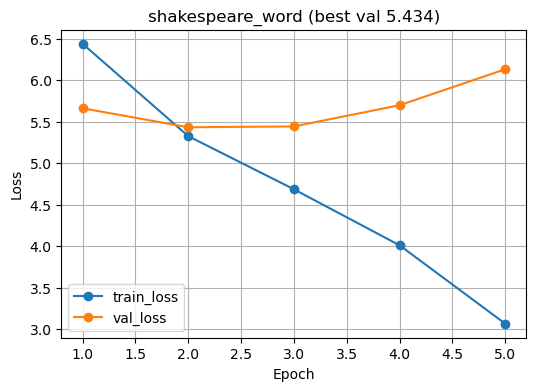

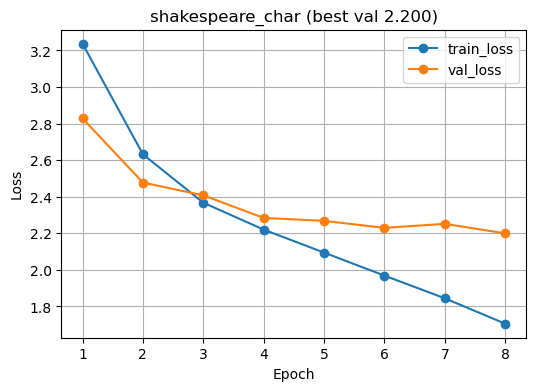

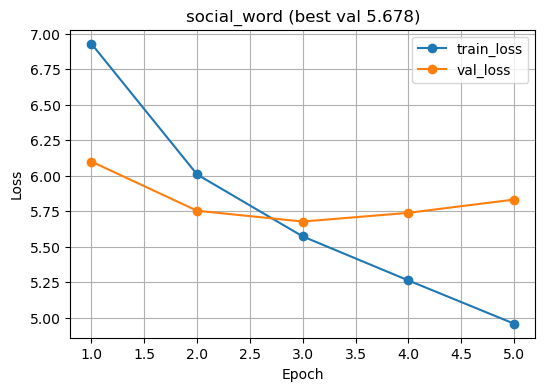

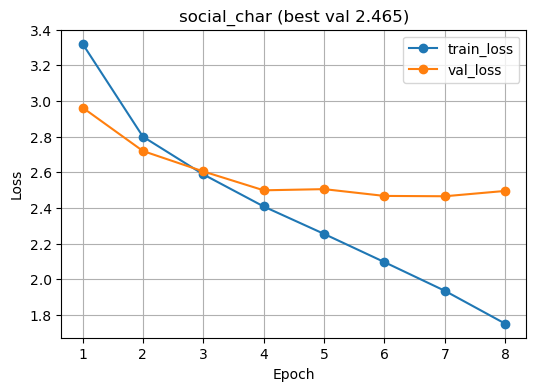

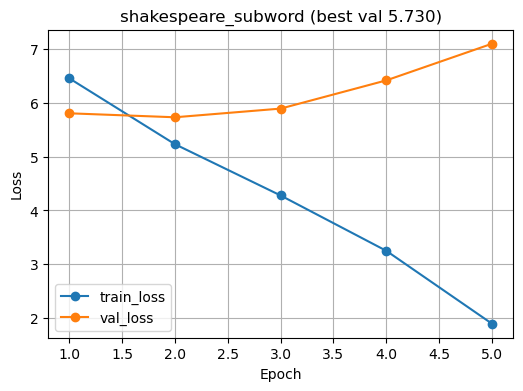

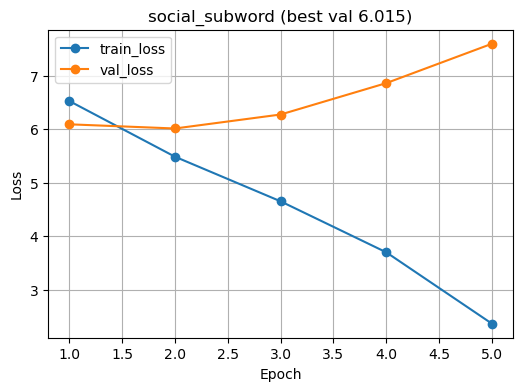

In [5]:

for model_name, rows in histories.items():
    epochs = [r["epoch"] for r in rows]
    train_loss = [r["train_loss"] for r in rows]
    val_loss = [r["val_loss"] for r in rows]
    best_val = min(val_loss) if val_loss else float('nan')
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, train_loss, marker="o", label="train_loss")
    plt.plot(epochs, val_loss, marker="o", label="val_loss")
    plt.title(f"{model_name} (best val {best_val:.3f})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


## Extension: Subword comparison

The two subword models are included as explicit extension experiments. The next cell compares each strict word model directly against its matching subword model so it is easy to see what changed: stricter vocabulary coverage, `<unk>` behavior, and the cost in loss/accuracy under the current CPU-friendly training budget.

In [6]:

comparison_pairs = [
    ("Shakespeare", "shakespeare_word", "shakespeare_subword"),
    ("Social media", "social_word", "social_subword"),
]
metrics_by_name = {row["model_name"]: row for row in metrics_rows}

def count_unk_tokens(model_name: str) -> int:
    return sum(sample["text"].count("<unk>") for sample in sample_outputs[model_name])

cols = [
    "corpus", "strict_word", "subword",
    "word_test_loss", "subword_test_loss",
    "word_known_rate", "subword_known_rate",
    "word_unk_rate", "subword_unk_rate",
    "word_sample_unk", "subword_sample_unk",
]
header = " | ".join(f"{c:>16}" for c in cols)
print(header)
print("-" * len(header))
for corpus_label, word_name, subword_name in comparison_pairs:
    word_row = metrics_by_name[word_name]
    subword_row = metrics_by_name[subword_name]
    values = {
        "corpus": corpus_label,
        "strict_word": word_name,
        "subword": subword_name,
        "word_test_loss": word_row["test_loss"],
        "subword_test_loss": subword_row["test_loss"],
        "word_known_rate": word_row.get("known_token_rate", ""),
        "subword_known_rate": subword_row.get("known_token_rate", ""),
        "word_unk_rate": word_row.get("unk_token_rate", ""),
        "subword_unk_rate": subword_row.get("unk_token_rate", ""),
        "word_sample_unk": count_unk_tokens(word_name),
        "subword_sample_unk": count_unk_tokens(subword_name),
    }
    line_parts = []
    for col in cols:
        val = values[col]
        if isinstance(val, float):
            line_parts.append(f"{val:>16.3f}")
        else:
            line_parts.append(f"{str(val):>16}")
    print(" | ".join(line_parts))


          corpus |      strict_word |          subword |   word_test_loss | subword_test_loss |  word_known_rate | subword_known_rate |    word_unk_rate | subword_unk_rate |  word_sample_unk | subword_sample_unk
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
     Shakespeare | shakespeare_word | shakespeare_subword |            5.355 |            6.125 |            0.921 |            1.000 |            0.079 |            0.000 |               41 |                0
    Social media |      social_word |   social_subword |            5.716 |            6.061 |            0.904 |            1.000 |            0.096 |            0.000 |               30 |                0


## Reusable loading and generation functions

In [7]:

MODEL_PATHS = {row["model_name"]: Path(row["model_file"]) for row in metrics_rows}

def load_project_model(model_name: str):
    return ph.load_model_bundle(MODEL_PATHS[model_name])

def default_length_for(bundle):
    granularity = bundle["metadata"]["granularity"]
    if granularity == "char":
        return 240
    if granularity == "subword":
        return 80
    return 50

def default_top_k_for(bundle):
    granularity = bundle["metadata"]["granularity"]
    if granularity == "char":
        return 8
    if granularity == "subword":
        return 16
    return 12

def quick_generate(
    model_name: str,
    prompt: str,
    length: int | None = None,
    temperature: float | None = None,
    top_k: int | None = None,
):
    bundle = load_project_model(model_name)
    granularity = bundle["metadata"]["granularity"]
    if length is None:
        length = default_length_for(bundle)
    if temperature is None:
        temperature = 0.9 if granularity in {"word", "subword"} else 0.8
    if top_k is None:
        top_k = default_top_k_for(bundle)
    return ph.generate_text(bundle, prompt=prompt, length=length, temperature=temperature, top_k=top_k)

# Demo: strict word vs subword on the same prompt
for demo_model in ["shakespeare_word", "shakespeare_subword"]:
    print(demo_model)
    print(quick_generate(demo_model, prompt="Love", temperature=0.9))
    print()


shakespeare_word
Love. <unk>, <unk> and,, <unk>, and and <unk>, for in, and. I it, in, the <unk> and,.,. I, my,. hamlet. this. But it. <unk> my lord,, I the <unk>

shakespeare_subword


Love.,s the.,ing,,,s theingi theg and, in, I the am,gs. The I the do. I their,,ingings, and., thess the,,sing anddent ad,s of, the Id,ings.. I, I. a to. The, I,



## Sample outputs with the same prompt family (`love `)

The assignment asks for 3-5 outputs per model. The cell below generates three deterministic samples for each primary model first, then three deterministic samples for each subword extension model, all from the same prompt family so the style differences are easy to compare. The subword block is intentionally separated so the extension models do not blur the main four-model submission comparison.

In [8]:

COMMON_PROMPT = "love "
SAMPLE_PLAN = {
    "shakespeare_word": [0.75, 0.90, 1.05],
    "shakespeare_char": [0.65, 0.80, 0.95],
    "social_word": [0.75, 0.90, 1.05],
    "social_char": [0.65, 0.80, 0.95],
    "shakespeare_subword": [0.70, 0.90, 1.10],
    "social_subword": [0.70, 0.90, 1.10],
}

sample_lengths = {
    "word": 50,
    "char": 240,
    "subword": 80,
}

generated_samples = {}
max_len = 500
for section_title, model_names in [
    ("Primary comparison models", PRIMARY_MODEL_NAMES),
    ("Extension: subword models", EXTENSION_MODEL_NAMES),
]:
    print("#" * 100)
    print(section_title)
    print("#" * 100)
    for model_name in model_names:
        temps = SAMPLE_PLAN[model_name]
        bundle = load_project_model(model_name)
        granularity = bundle["metadata"]["granularity"]
        generated_samples[model_name] = []
        print("=" * 100)
        print(model_name)
        for idx, temp in enumerate(temps, start=1):
            ph.set_seed(ph.DEFAULT_SEED + idx)
            top_k = default_top_k_for(bundle)
            text = ph.generate_text(
                bundle,
                prompt=COMMON_PROMPT,
                length=sample_lengths[granularity],
                temperature=temp,
                top_k=top_k,
            )
            generated_samples[model_name].append({"temperature": temp, "text": text})
            display_text = text if len(text) <= max_len else text[:max_len] + "..."
            print(f"sample={idx} temperature={temp}")
            print(display_text)
            print()


####################################################################################################
Primary comparison models
####################################################################################################
shakespeare_word
sample=1 temperature=0.75
love, <unk>? and <unk>, <unk>, <unk>. for,., and,, <unk>. <unk> <unk>,. I,. and. <unk>, I, it, <unk> <unk> in the <unk> <unk>,, <unk> and, the <unk>., <unk>



sample=2 temperature=0.9
love., <unk>. But, <unk>, in this <unk>. <unk>, this I, the <unk>. for,, I <unk>, <unk>, <unk>, <unk>,, and and. But you it to is <unk>, in the <unk> and;,.

sample=3 temperature=1.05
love,, and I, a <unk>. and, <unk> the of, and, and in the, <unk> in the <unk> <unk>? <unk> <unk> the <unk>, the the <unk>, the and. <unk> to <unk>, and, <unk> <unk> <unk> <unk>. and

shakespeare_char


sample=1 temperature=0.65
love that and where for thour that his mone now his ming and in she and fill. RAALTAI. What hing shers, Onother mand in there and and ing whan the thing wo lies ing whing. Bour the mind shend ing what his time sterd Hom erance the the ming and p



sample=2 temperature=0.8
love the ing will, sell nowe. HAMLET. I therer to there late fillis ing will. OI Is mot ing whill sere what and seat ing this and it of the ath ing whill. HAMIE. Whe mome ing what what we mave it there she my his, and ing and mand fimer that him



sample=3 temperature=0.95
love shise mave thing siggnt, wince ting se mond and mother, HAMTET. And frould my uss lies, my has to the miset sir, I mont. Boust mother, Home mamins, and sime my hard. Hamlis, ing will ther follide will thing mint whole, my for mothes mest se

social_word
sample=1 temperature=0.75
love <unk> I am I..... @USER I'm <unk>, and.... @USER <unk>.. is <unk> <unk> is <unk>! <unk>............... <unk>... <unk>.

sample=2 temperature=0.9
love <unk> <unk> and. @USER <unk> <unk> <unk>. i <unk>....! <unk> @USER <unk>. the <unk>........... <unk>!..... I'm <unk>.! <unk> <unk> and and <unk> to

sample=3 temperature=1.05
love @USER <unk> I @USER I have I. the <unk>.!! I I. I no. <unk>.! @USER <unk> I am. <unk> <unk>...... I a <NUM> <unk> the....... @USER..

social_char


...

sample=2 temperature=0.9
love, you and the,., anding, I havesing the anding, ands the,, si.dingingg,p, v, ining a Iss and have the, of and thet. inss., I theinging andsgs, I. Is. sing the.d s andg



sample=3 temperature=1.1
lovesing it.s of it.p;a Is.s in the Is of, I  e, to.. And. him.. it.,. my its,, a.py.,ings, I a, I  your, yours of I a, aingiirssingol. I a , I it

social_subword


sample=1 temperature=0.7
love I I's s'ss the the Ieeing to thes mas' to and' to tos doeing and. Io's i the to. my s. Itms I Iios I as I Ite as I te seo it 'sses 



sample=2 temperature=0.9
love it on'ts Ia to s. Ia ..it @seomab is I! thea totas mes meing. i It tto? i I'm Iisiting! I Im theed it et ito I en mye it,  toaning of I



sample=3 temperature=1.1
lovetie to!. mys @respet ed.b @tsoooro I I s't a   itings I the! @ss to. my mys sts  ppsed theos Itasa me! i Imiming to be @sean



## Qualitative observations

- Character models remain the strongest models in this package. `shakespeare_char` finished with test loss 2.204 / accuracy 0.386, and `social_char` finished with test loss 2.442 / accuracy 0.338. They still preserve local style and punctuation better than the token-based alternatives.
- The strict word models are meaningfully fairer after the tokenizer fix. `shakespeare_word` now keeps about 92.1% of training tokens in-vocabulary and `social_word` keeps about 90.4%, versus the much heavier `<unk>` pressure in the earlier run. They still emit `<unk>` in generation, but far less aggressively than before.
- The two subword extension models remove the `<unk>` problem entirely in the saved samples because they use per-corpus SentencePiece tokenizers instead of a frequency-limited word vocabulary. That confirms the OOV bottleneck was real.
- Removing OOV pressure alone did not make the subword models the best models in this CPU-friendly setup. After six epochs, both subword models still have higher loss than the strict word and char models, so the extension should be framed as a vocabulary-handling experiment rather than a replacement for the assignment's main comparison.
- Corpus style remains the clearest signal across all six models. Shakespeare generations surface speaker names, formal phrasing, and stage-like rhythm, while the social-media models lean toward first-person language, shorter bursts, mentions, and informal punctuation.
- The final artifacts support a cleaner conclusion than the earlier submission: corpus choice controls style, tokenizer granularity controls the error mode, and reducing `<unk>` pressure improves the word-level comparison even when character models still win on overall fluency.

## Dataset source links

See `dataset_sources.md` for the exact source links, prepared-file paths, tokenizer notes, and strict-word normalization rules used by the final run. The tokenizer asset paths for the two subword extension models are also recorded in `artifacts/corpus_stats.json`.